<a href="https://colab.research.google.com/github/JordanTerwilliger/Intro-to-Deep-Learning/blob/main/HW4/HW4_NLP_Transformer_Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jordan Terwilliger, 801343938, HW4

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import requests

from torch import nn
from torch import functional as F
from torch import optim

!pip install torchinfo

import matplotlib.pyplot as plt

from torchinfo import summary

In [ ]:
torch.manual_seed(1)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
text = response.text  # This is the entire text data
chars = sorted(list(set(text)))
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}
# Encode the text into integers
all_data = torch.tensor([char_to_int[ch] for ch in text], dtype=torch.long)

# 2. Split into Train and Test slices directly (80% / 20%)
n = int(0.8 * len(all_data))
train_data = all_data[:n]
val_data = all_data[n:]

# 3. Fast random batch fetcher function (No DataLoader overhead!)
def get_batch(split, batch_size=4096, sequence_length=128, device='cuda'):
    data = train_data if split == 'train' else val_data

    # Generate random starting indices for the batch
    ix = torch.randint(len(data) - sequence_length, (batch_size,))

    # Extract sequences and target characters using tensor slicing
    x = torch.stack([data[i : i + sequence_length] for i in ix])
    y = torch.stack([data[i + sequence_length] for i in ix]) # Shape becomes [4096]

    # Push immediately to device
    return x.to(device), y.to(device)

In [ ]:
# We need to convert this text into a list of sorted indices for
print(f"Total Input Characters: {len(text)}")
sorted_text = list(sorted(set(text)))
print(f"Total Unique Characters: {len(sorted_text)}")
print(sorted_text)

ix_to_char = {i: ch for i,ch in enumerate(sorted_text)}
print(ix_to_char)

char_to_ix = {ch: i for i, ch in enumerate(sorted_text)}

Total Input Characters: 1115394
Total Unique Characters: 65
['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{0: '\n', 1: ' ', 2: '!', 3: '$', 4: '&', 5: "'", 6: ',', 7: '-', 8: '.', 9: '3', 10: ':', 11: ';', 12: '?', 13: 'A', 14: 'B', 15: 'C', 16: 'D', 17: 'E', 18: 'F', 19: 'G', 20: 'H', 21: 'I', 22: 'J', 23: 'K', 24: 'L', 25: 'M', 26: 'N', 27: 'O', 28: 'P', 29: 'Q', 30: 'R', 31: 'S', 32: 'T', 33: 'U', 34: 'V', 35: 'W', 36: 'X', 37: 'Y', 38: 'Z', 39: 'a', 40: 'b', 41: 'c', 42: 'd', 43: 'e', 44: 'f', 45: 'g', 46: 'h', 47: 'i', 48: 'j', 49: 'k', 50: 'l', 51: 'm', 52: 'n', 53: 'o', 54: 'p', 55: 'q', 56: 'r', 57: 's', 58: 't', 59: 'u', 60: 'v', 61: 'w', 62: 'x', 63: 'y', 64: 'z'}


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.encoding = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        self.encoding[:, 0::2] = torch.sin(position * div_term)
        self.encoding[:, 1::2] = torch.cos(position * div_term)
        self.encoding = self.encoding.unsqueeze(0).to(device)

    def forward(self, x):
        return x + self.encoding[:, :x.size(1)].detach()

#Create Model
class TransformerModel(nn.Module):
  def __init__(self, input_size, output_size, hidden_size, nhead, num_layers):
    super(TransformerModel, self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.pos_encoder = PositionalEncoding(hidden_size)
    encoder_layers = nn.TransformerEncoderLayer(hidden_size, nhead, batch_first=True)
    self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    embedded = self.pos_encoder(self.embedding(x))
    transformer_output = self.transformer_encoder(embedded)
    return self.fc(transformer_output[:, -1, :])

In [ ]:
def createPlot(sequence_length, train_loss_list, val_loss_list, val_accuracy_list):
  plt.figure(figsize=(12, 5))

  # Plot Loss
  plt.subplot(1, 2, 1)
  plt.plot(train_loss_list, label='Train Loss')
  plt.plot(val_loss_list, label='Val Loss')
  plt.title(f'Loss Curves Sequence Length:{sequence_length}')
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()

  # Plot Accuracy
  plt.subplot(1, 2, 2)
  plt.plot(val_accuracy_list, label='Val Accuracy')
  plt.title(f'Validation Accuracy Sequence Length:{sequence_length}')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy (%)')
  plt.legend()

  plt.show()

#2 transformer blocks, 2 heads

In [ ]:
#Hyperparameters
hidden_size = 512
num_layers = 2
nhead = 2
lr = 0.001
epochs = 50
input_size = len(sorted_text)

input_lengths = [20, 30]

model = TransformerModel(len(sorted_text), len(sorted_text), hidden_size, nhead, num_layers).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = lr)

Epoch 0, Loss: 4.3190, Val Accuracy: 0.1501, Val Loss: 5.0912
Training time for Epoch 0: 0.887218 seconds
Epoch 1, Loss: 2.4728, Val Accuracy: 0.0825, Val Loss: 4.5313
Training time for Epoch 1: 0.216754 seconds
Epoch 2, Loss: 1.4790, Val Accuracy: 0.0781, Val Loss: 4.1872
Training time for Epoch 2: 0.216813 seconds
Epoch 3, Loss: 1.0409, Val Accuracy: 0.0913, Val Loss: 4.0369
Training time for Epoch 3: 0.216789 seconds
Epoch 4, Loss: 0.8015, Val Accuracy: 0.0491, Val Loss: 3.7598
Training time for Epoch 4: 0.217045 seconds
Epoch 5, Loss: 0.6172, Val Accuracy: 0.1562, Val Loss: 3.4642
Training time for Epoch 5: 0.216812 seconds
Epoch 6, Loss: 0.4947, Val Accuracy: 0.1506, Val Loss: 3.5208
Training time for Epoch 6: 0.216770 seconds
Epoch 7, Loss: 0.4361, Val Accuracy: 0.1577, Val Loss: 3.3914
Training time for Epoch 7: 0.217058 seconds
Epoch 8, Loss: 0.3774, Val Accuracy: 0.1519, Val Loss: 3.2726
Training time for Epoch 8: 0.216818 seconds
Epoch 9, Loss: 0.3302, Val Accuracy: 0.0850, V

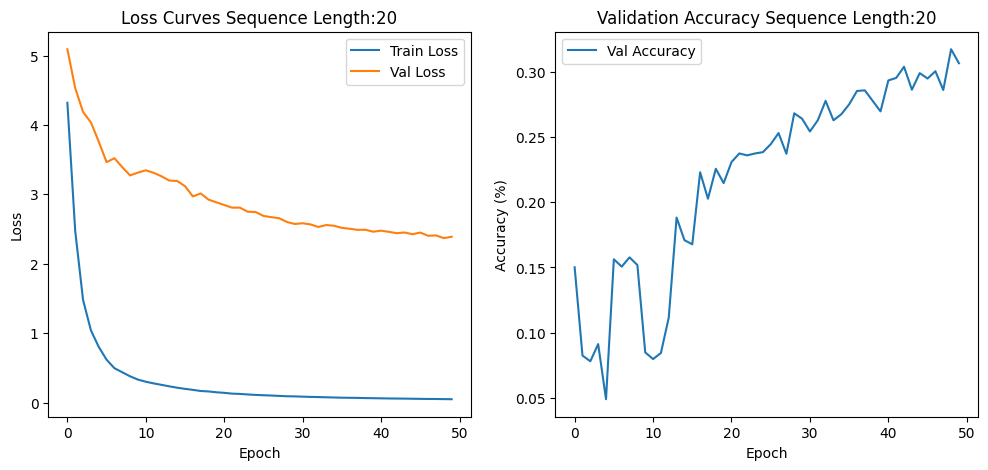

Layer (type:depth-idx)                        Output Shape              Param #
TransformerModel                              [1, 65]                   --
├─Embedding: 1-1                              [1, 65, 512]              33,280
├─PositionalEncoding: 1-2                     [1, 65, 512]              --
├─TransformerEncoder: 1-3                     [1, 65, 512]              --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 65, 512]              3,152,384
│    │    └─TransformerEncoderLayer: 3-2      [1, 65, 512]              3,152,384
├─Linear: 1-4                                 [1, 65]                   33,345
Total params: 6,371,393
Trainable params: 6,371,393
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.27
Input size (MB): 0.00
Forward/backward pass size (MB): 3.99
Params size (MB): 17.08
Estimated Total Size (MB): 21.08
Epoch 0, Loss: 2.7256, Val Accuracy: 0.2529, Val Loss: 2.6894
Tra

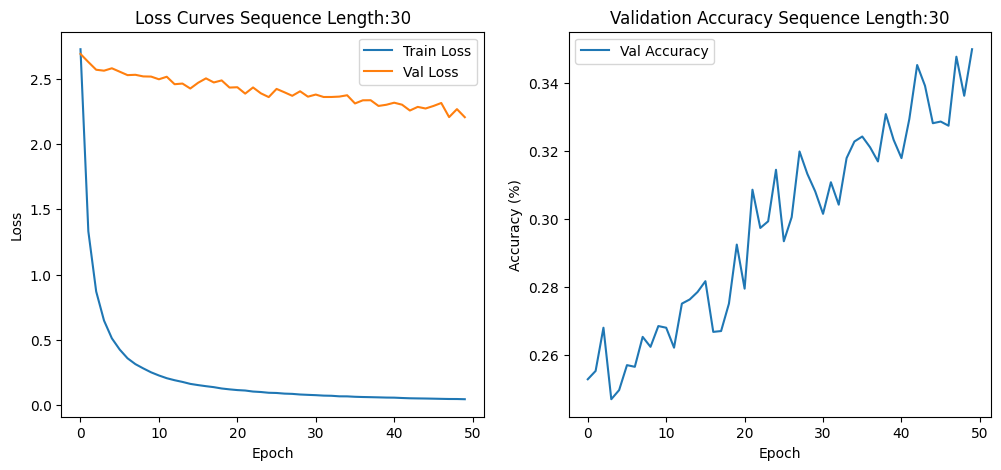

Layer (type:depth-idx)                        Output Shape              Param #
TransformerModel                              [1, 65]                   --
├─Embedding: 1-1                              [1, 65, 512]              33,280
├─PositionalEncoding: 1-2                     [1, 65, 512]              --
├─TransformerEncoder: 1-3                     [1, 65, 512]              --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 65, 512]              3,152,384
│    │    └─TransformerEncoderLayer: 3-2      [1, 65, 512]              3,152,384
├─Linear: 1-4                                 [1, 65]                   33,345
Total params: 6,371,393
Trainable params: 6,371,393
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.27
Input size (MB): 0.00
Forward/backward pass size (MB): 3.99
Params size (MB): 17.08
Estimated Total Size (MB): 21.08


In [ ]:
for seq_len in input_lengths:


# Training Loop
  #Lists for storing loss and validation values
  train_loss_list = []
  val_loss_list = []
  val_accuracy_list = []
  train_batches = 0

  #Create a new training loop for each input_length
  for epoch in range(epochs):
    X_train, y_train = get_batch('train', sequence_length=seq_len)

    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    start_event.record()
    model.train()

    epoch_train_loss = 0.0

    optimizer.zero_grad(set_to_none=True)
    y_pred = model(X_train)  # Forward pass
    loss = criterion(y_pred, y_train)  # Compute loss
    loss.backward()  # Backward pass
    optimizer.step()  # Update model parameters

    epoch_train_loss += loss.item()
    train_batches += 1

    end_event.record()
    torch.cuda.synchronize()
    # Calculate time in milliseconds
    elapsed_time_ms = start_event.elapsed_time(end_event)


# Validation Loop
    model.eval()

    total_val_loss = 0.0
    total_val_acc = 0.0
    val_batches = 0

    with torch.no_grad():
      X_val, y_val = get_batch('test', sequence_length=seq_len)

      val_output = model(X_val)
      val_loss = criterion(val_output, y_val) #Find the loss

      predicted = torch.argmax(val_output, 1) #Here we find what the output was (what letter)
      val_accuracy = (predicted == y_val).float().mean()

      total_val_loss += val_loss.item()
      total_val_acc += val_accuracy.item()
      val_batches += 1

    # Compute genuine averages across the whole dataset split
    avg_train_loss = epoch_train_loss / train_batches
    avg_val_loss = total_val_loss / val_batches
    avg_val_acc = total_val_acc / val_batches

    # Append true averages to history lists
    train_loss_list.append(avg_train_loss)
    val_loss_list.append(avg_val_loss)
    val_accuracy_list.append(avg_val_acc)

    if (epoch % 1 == 0):
      print(f'Epoch {epoch}, Loss: {avg_train_loss:.4f}, Val Accuracy: {avg_val_acc:.4f}, Val Loss: {avg_val_loss:.4f}')
      print(f"Training time for Epoch {epoch}: {elapsed_time_ms / 1000:.6f} seconds")
  createPlot(seq_len, train_loss_list, val_loss_list, val_accuracy_list)
  print(summary(model, input_size = (1,input_size), dtypes=[torch.long]))



In [ ]:
def predictNextChar(model, char_to_ix, ix_to_char, initial_str):
  model.eval()
  with torch.no_grad():
    initial_input = torch.tensor([char_to_ix[c] for c in initial_str], dtype=torch.long).unsqueeze(0).to(device)
    prediction = model(initial_input)
    predicted_index = torch.argmax(prediction, dim=1).item()
    return ix_to_char[predicted_index]

In [ ]:
test_str = " "
for _ in range(30):
  predicted_char = predictNextChar(model, char_to_ix, ix_to_char, test_str)
  test_str += predicted_char
  print(f"Predicted next character: '{test_str}'")

Predicted next character: ' t'
Predicted next character: ' t '
Predicted next character: ' t h'
Predicted next character: ' t he'
Predicted next character: ' t he '
Predicted next character: ' t he t'
Predicted next character: ' t he t '
Predicted next character: ' t he t t'
Predicted next character: ' t he t t '
Predicted next character: ' t he t t t'
Predicted next character: ' t he t t t '
Predicted next character: ' t he t t t t'
Predicted next character: ' t he t t t t '
Predicted next character: ' t he t t t t t'
Predicted next character: ' t he t t t t t '
Predicted next character: ' t he t t t t t t'
Predicted next character: ' t he t t t t t t '
Predicted next character: ' t he t t t t t t t'
Predicted next character: ' t he t t t t t t t '
Predicted next character: ' t he t t t t t t t t'
Predicted next character: ' t he t t t t t t t t '
Predicted next character: ' t he t t t t t t t t t'
Predicted next character: ' t he t t t t t t t t t '
Predicted next character: ' t he t

#1 transformer block, 2 heads

In [ ]:
#Hyperparameters
num_layers = 1
nhead = 2

model = TransformerModel(len(sorted_text), len(sorted_text), hidden_size, nhead, num_layers).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = lr)

Epoch 0, Loss: 4.4205, Val Accuracy: 0.1592, Val Loss: 3.8110
Training time for Epoch 0: 0.109181 seconds
Epoch 1, Loss: 1.8611, Val Accuracy: 0.1086, Val Loss: 3.4854
Training time for Epoch 1: 0.109132 seconds
Epoch 2, Loss: 1.1594, Val Accuracy: 0.1572, Val Loss: 3.3958
Training time for Epoch 2: 0.109319 seconds
Epoch 3, Loss: 0.8401, Val Accuracy: 0.1499, Val Loss: 3.3043
Training time for Epoch 3: 0.109134 seconds
Epoch 4, Loss: 0.6526, Val Accuracy: 0.2195, Val Loss: 3.0814
Training time for Epoch 4: 0.109044 seconds
Epoch 5, Loss: 0.5125, Val Accuracy: 0.2317, Val Loss: 2.9260
Training time for Epoch 5: 0.109100 seconds
Epoch 6, Loss: 0.4178, Val Accuracy: 0.2192, Val Loss: 2.9840
Training time for Epoch 6: 0.109115 seconds
Epoch 7, Loss: 0.3689, Val Accuracy: 0.2378, Val Loss: 2.8535
Training time for Epoch 7: 0.109070 seconds
Epoch 8, Loss: 0.3165, Val Accuracy: 0.2358, Val Loss: 2.8285
Training time for Epoch 8: 0.109108 seconds
Epoch 9, Loss: 0.2802, Val Accuracy: 0.2312, V

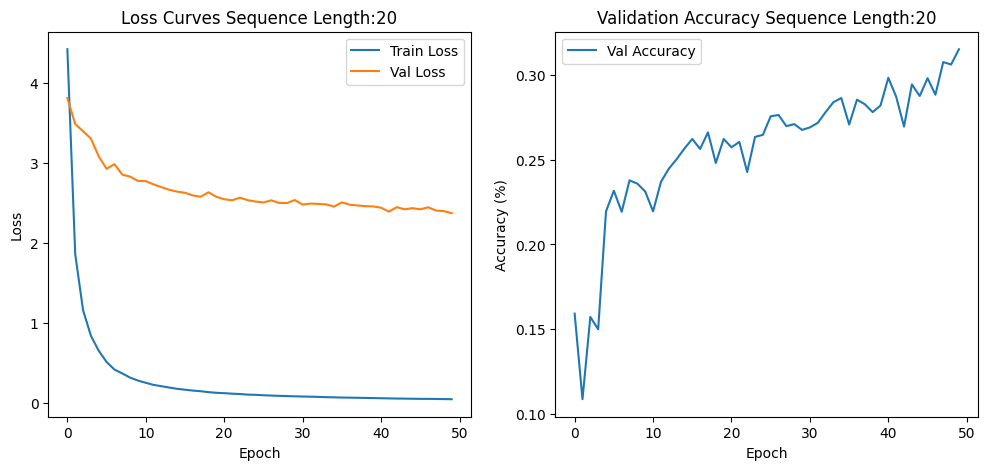

Layer (type:depth-idx)                        Output Shape              Param #
TransformerModel                              [1, 65]                   --
├─Embedding: 1-1                              [1, 65, 512]              33,280
├─PositionalEncoding: 1-2                     [1, 65, 512]              --
├─TransformerEncoder: 1-3                     [1, 65, 512]              --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 65, 512]              3,152,384
├─Linear: 1-4                                 [1, 65]                   33,345
Total params: 3,219,009
Trainable params: 3,219,009
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.17
Input size (MB): 0.00
Forward/backward pass size (MB): 2.13
Params size (MB): 8.67
Estimated Total Size (MB): 10.80
Epoch 0, Loss: 2.6043, Val Accuracy: 0.2507, Val Loss: 2.5592
Training time for Epoch 0: 0.158825 seconds
Epoch 1, Loss: 1.2613, Val Accuracy: 0.270

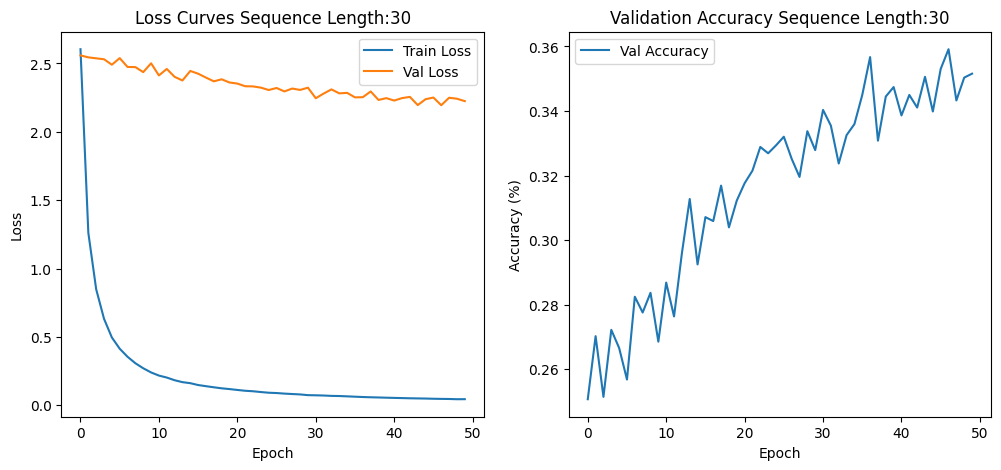

Layer (type:depth-idx)                        Output Shape              Param #
TransformerModel                              [1, 65]                   --
├─Embedding: 1-1                              [1, 65, 512]              33,280
├─PositionalEncoding: 1-2                     [1, 65, 512]              --
├─TransformerEncoder: 1-3                     [1, 65, 512]              --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 65, 512]              3,152,384
├─Linear: 1-4                                 [1, 65]                   33,345
Total params: 3,219,009
Trainable params: 3,219,009
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.17
Input size (MB): 0.00
Forward/backward pass size (MB): 2.13
Params size (MB): 8.67
Estimated Total Size (MB): 10.80


In [ ]:
for seq_len in input_lengths:


# Training Loop
  #Lists for storing loss and validation values
  train_loss_list = []
  val_loss_list = []
  val_accuracy_list = []
  train_batches = 0

  #Create a new training loop for each input_length
  for epoch in range(epochs):
    X_train, y_train = get_batch('train', sequence_length=seq_len)

    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    start_event.record()
    model.train()

    epoch_train_loss = 0.0

    optimizer.zero_grad()
    y_pred = model(X_train)  # Forward pass
    loss = criterion(y_pred, y_train)  # Compute loss
    loss.backward()  # Backward pass
    optimizer.step()  # Update model parameters

    epoch_train_loss += loss.item()
    train_batches += 1

    end_event.record()
    torch.cuda.synchronize()
    # Calculate time in milliseconds
    elapsed_time_ms = start_event.elapsed_time(end_event)


# Validation Loop
    model.eval()

    total_val_loss = 0.0
    total_val_acc = 0.0
    val_batches = 0

    with torch.no_grad():
      X_val, y_val = get_batch('test', sequence_length=seq_len)

      val_output = model(X_val)
      val_loss = criterion(val_output, y_val) #Find the loss

      predicted = torch.argmax(val_output, 1) #Here we find what the output was (what letter)
      val_accuracy = (predicted == y_val).float().mean()

      total_val_loss += val_loss.item()
      total_val_acc += val_accuracy.item()
      val_batches += 1

    # Compute genuine averages across the whole dataset split
    avg_train_loss = epoch_train_loss / train_batches
    avg_val_loss = total_val_loss / val_batches
    avg_val_acc = total_val_acc / val_batches

    # Append true averages to history lists
    train_loss_list.append(avg_train_loss)
    val_loss_list.append(avg_val_loss)
    val_accuracy_list.append(avg_val_acc)

    if (epoch % 1 == 0):
      print(f'Epoch {epoch}, Loss: {avg_train_loss:.4f}, Val Accuracy: {avg_val_acc:.4f}, Val Loss: {avg_val_loss:.4f}')
      print(f"Training time for Epoch {epoch}: {elapsed_time_ms / 1000:.6f} seconds")
  createPlot(seq_len, train_loss_list, val_loss_list, val_accuracy_list)
  print(summary(model, input_size = (1,input_size), dtypes=[torch.long]))



In [ ]:
def predictNextChar(model, char_to_ix, ix_to_char, initial_str):
  model.eval()
  with torch.no_grad():
    initial_input = torch.tensor([char_to_ix[c] for c in initial_str], dtype=torch.long).unsqueeze(0).to(device)
    prediction = model(initial_input)
    predicted_index = torch.argmax(prediction, dim=1).item()
    return ix_to_char[predicted_index]

In [ ]:
test_str = " "
for _ in range(30):
  predicted_char = predictNextChar(model, char_to_ix, ix_to_char, test_str)
  test_str += predicted_char
  print(f"Predicted next character: '{test_str}'")

Predicted next character: ' a'
Predicted next character: ' ar'
Predicted next character: ' are'
Predicted next character: ' are '
Predicted next character: ' are t'
Predicted next character: ' are th'
Predicted next character: ' are the'
Predicted next character: ' are the '
Predicted next character: ' are the t'
Predicted next character: ' are the th'
Predicted next character: ' are the the'
Predicted next character: ' are the the '
Predicted next character: ' are the the t'
Predicted next character: ' are the the th'
Predicted next character: ' are the the the'
Predicted next character: ' are the the the '
Predicted next character: ' are the the the t'
Predicted next character: ' are the the the t '
Predicted next character: ' are the the the t t'
Predicted next character: ' are the the the t th'
Predicted next character: ' are the the the t the'
Predicted next character: ' are the the the t the '
Predicted next character: ' are the the the t the m'
Predicted next character: ' are th

#1 transformer block , 4 heads

In [ ]:
#Hyperparameters
num_layers = 1
nhead = 4

model = TransformerModel(len(sorted_text), len(sorted_text), hidden_size, nhead, num_layers).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = lr)

Epoch 0, Loss: 4.4109, Val Accuracy: 0.1594, Val Loss: 3.9556
Training time for Epoch 0: 0.111414 seconds
Epoch 1, Loss: 1.9725, Val Accuracy: 0.1172, Val Loss: 3.4761
Training time for Epoch 1: 0.111022 seconds
Epoch 2, Loss: 1.1391, Val Accuracy: 0.1770, Val Loss: 3.4632
Training time for Epoch 2: 0.110971 seconds
Epoch 3, Loss: 0.8667, Val Accuracy: 0.1870, Val Loss: 3.3349
Training time for Epoch 3: 0.110996 seconds
Epoch 4, Loss: 0.6677, Val Accuracy: 0.1973, Val Loss: 3.1346
Training time for Epoch 4: 0.111002 seconds
Epoch 5, Loss: 0.5251, Val Accuracy: 0.2346, Val Loss: 2.9623
Training time for Epoch 5: 0.111017 seconds
Epoch 6, Loss: 0.4190, Val Accuracy: 0.2129, Val Loss: 2.9319
Training time for Epoch 6: 0.111065 seconds
Epoch 7, Loss: 0.3661, Val Accuracy: 0.2146, Val Loss: 2.9142
Training time for Epoch 7: 0.111012 seconds
Epoch 8, Loss: 0.3190, Val Accuracy: 0.2356, Val Loss: 2.8208
Training time for Epoch 8: 0.110979 seconds
Epoch 9, Loss: 0.2830, Val Accuracy: 0.2322, V

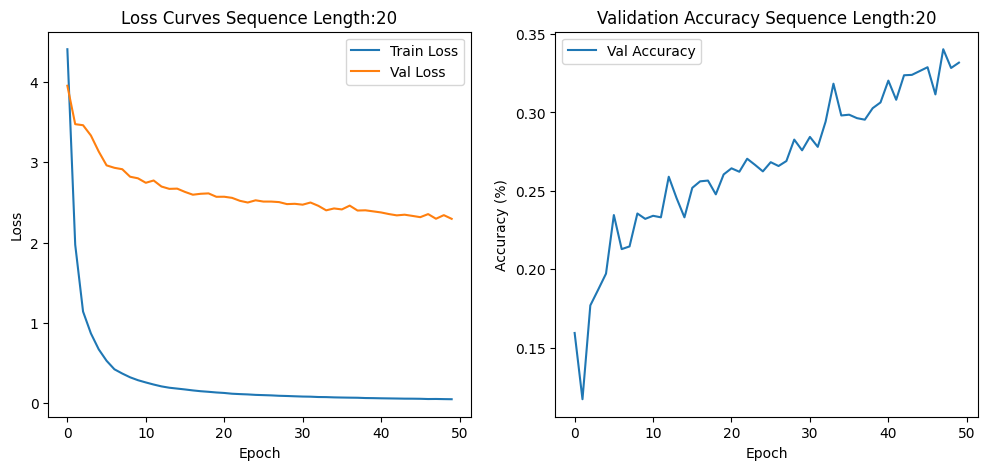

Layer (type:depth-idx)                        Output Shape              Param #
TransformerModel                              [1, 65]                   --
├─Embedding: 1-1                              [1, 65, 512]              33,280
├─PositionalEncoding: 1-2                     [1, 65, 512]              --
├─TransformerEncoder: 1-3                     [1, 65, 512]              --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 65, 512]              3,152,384
├─Linear: 1-4                                 [1, 65]                   33,345
Total params: 3,219,009
Trainable params: 3,219,009
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.17
Input size (MB): 0.00
Forward/backward pass size (MB): 2.13
Params size (MB): 8.67
Estimated Total Size (MB): 10.80
Epoch 0, Loss: 2.6865, Val Accuracy: 0.2473, Val Loss: 2.6167
Training time for Epoch 0: 0.160231 seconds
Epoch 1, Loss: 1.2913, Val Accuracy: 0.253

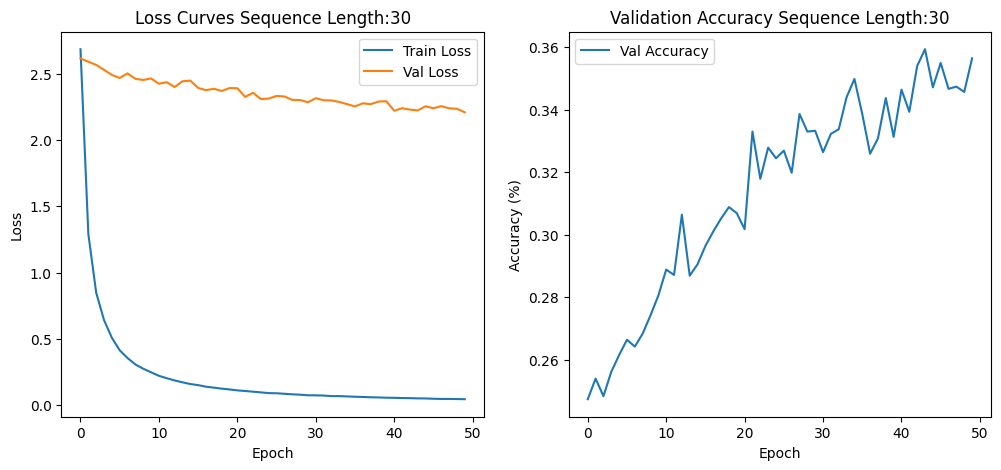

Layer (type:depth-idx)                        Output Shape              Param #
TransformerModel                              [1, 65]                   --
├─Embedding: 1-1                              [1, 65, 512]              33,280
├─PositionalEncoding: 1-2                     [1, 65, 512]              --
├─TransformerEncoder: 1-3                     [1, 65, 512]              --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 65, 512]              3,152,384
├─Linear: 1-4                                 [1, 65]                   33,345
Total params: 3,219,009
Trainable params: 3,219,009
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.17
Input size (MB): 0.00
Forward/backward pass size (MB): 2.13
Params size (MB): 8.67
Estimated Total Size (MB): 10.80


In [ ]:
for seq_len in input_lengths:


# Training Loop
  #Lists for storing loss and validation values
  train_loss_list = []
  val_loss_list = []
  val_accuracy_list = []
  train_batches = 0

  #Create a new training loop for each input_length
  for epoch in range(epochs):
    X_train, y_train = get_batch('train', sequence_length=seq_len)

    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    start_event.record()
    model.train()

    epoch_train_loss = 0.0

    optimizer.zero_grad()
    y_pred = model(X_train)  # Forward pass
    loss = criterion(y_pred, y_train)  # Compute loss
    loss.backward()  # Backward pass
    optimizer.step()  # Update model parameters

    epoch_train_loss += loss.item()
    train_batches += 1

    end_event.record()
    torch.cuda.synchronize()
    # Calculate time in milliseconds
    elapsed_time_ms = start_event.elapsed_time(end_event)


# Validation Loop
    model.eval()

    total_val_loss = 0.0
    total_val_acc = 0.0
    val_batches = 0

    with torch.no_grad():
      X_val, y_val = get_batch('test', sequence_length=seq_len)

      val_output = model(X_val)
      val_loss = criterion(val_output, y_val) #Find the loss

      predicted = torch.argmax(val_output, 1) #Here we find what the output was (what letter)
      val_accuracy = (predicted == y_val).float().mean()

      total_val_loss += val_loss.item()
      total_val_acc += val_accuracy.item()
      val_batches += 1

    # Compute genuine averages across the whole dataset split
    avg_train_loss = epoch_train_loss / train_batches
    avg_val_loss = total_val_loss / val_batches
    avg_val_acc = total_val_acc / val_batches

    # Append true averages to history lists
    train_loss_list.append(avg_train_loss)
    val_loss_list.append(avg_val_loss)
    val_accuracy_list.append(avg_val_acc)

    if (epoch % 1 == 0):
      print(f'Epoch {epoch}, Loss: {avg_train_loss:.4f}, Val Accuracy: {avg_val_acc:.4f}, Val Loss: {avg_val_loss:.4f}')
      print(f"Training time for Epoch {epoch}: {elapsed_time_ms / 1000:.6f} seconds")
  createPlot(seq_len, train_loss_list, val_loss_list, val_accuracy_list)
  print(summary(model, input_size = (1,input_size), dtypes=[torch.long]))



In [ ]:
def predictNextChar(model, char_to_ix, ix_to_char, initial_str):
  model.eval()
  with torch.no_grad():
    initial_input = torch.tensor([char_to_ix[c] for c in initial_str], dtype=torch.long).unsqueeze(0).to(device)
    prediction = model(initial_input)
    predicted_index = torch.argmax(prediction, dim=1).item()
    return ix_to_char[predicted_index]

In [ ]:
test_str = " "
for _ in range(30):
  predicted_char = predictNextChar(model, char_to_ix, ix_to_char, test_str)
  test_str += predicted_char
  print(f"Predicted next character: '{test_str}'")

Predicted next character: ' I'
Predicted next character: ' I:'
Predicted next character: ' I:
'
Predicted next character: ' I:
I'
Predicted next character: ' I:
I '
Predicted next character: ' I:
I a'
Predicted next character: ' I:
I ai'
Predicted next character: ' I:
I aie'
Predicted next character: ' I:
I aie '
Predicted next character: ' I:
I aie t'
Predicted next character: ' I:
I aie th'
Predicted next character: ' I:
I aie the'
Predicted next character: ' I:
I aie the '
Predicted next character: ' I:
I aie the t'
Predicted next character: ' I:
I aie the th'
Predicted next character: ' I:
I aie the the'
Predicted next character: ' I:
I aie the the '
Predicted next character: ' I:
I aie the the t'
Predicted next character: ' I:
I aie the the th'
Predicted next character: ' I:
I aie the the the'
Predicted next character: ' I:
I aie the the thea'
Predicted next character: ' I:
I aie the the thean'
Predicted next character: ' I:
I aie the the theand'
Predicted next character: ' I:
I a

#2 transformer blocks, 4 heads

In [ ]:
#Hyperparameters
num_layers = 2
nhead = 4

model = TransformerModel(len(sorted_text), len(sorted_text), hidden_size, nhead, num_layers).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = lr)

Epoch 0, Loss: 4.3174, Val Accuracy: 0.1492, Val Loss: 4.3621
Training time for Epoch 0: 0.220648 seconds
Epoch 1, Loss: 2.1157, Val Accuracy: 0.0671, Val Loss: 3.9754
Training time for Epoch 1: 0.220562 seconds
Epoch 2, Loss: 1.3196, Val Accuracy: 0.1052, Val Loss: 3.9315
Training time for Epoch 2: 0.220505 seconds
Epoch 3, Loss: 0.9633, Val Accuracy: 0.1458, Val Loss: 3.7465
Training time for Epoch 3: 0.220514 seconds
Epoch 4, Loss: 0.7435, Val Accuracy: 0.1511, Val Loss: 3.4748
Training time for Epoch 4: 0.220505 seconds
Epoch 5, Loss: 0.5711, Val Accuracy: 0.1631, Val Loss: 3.2489
Training time for Epoch 5: 0.220802 seconds
Epoch 6, Loss: 0.4610, Val Accuracy: 0.1511, Val Loss: 3.2980
Training time for Epoch 6: 0.220479 seconds
Epoch 7, Loss: 0.4069, Val Accuracy: 0.1836, Val Loss: 3.0762
Training time for Epoch 7: 0.220765 seconds
Epoch 8, Loss: 0.3435, Val Accuracy: 0.1877, Val Loss: 3.1105
Training time for Epoch 8: 0.220477 seconds
Epoch 9, Loss: 0.3046, Val Accuracy: 0.2073, V

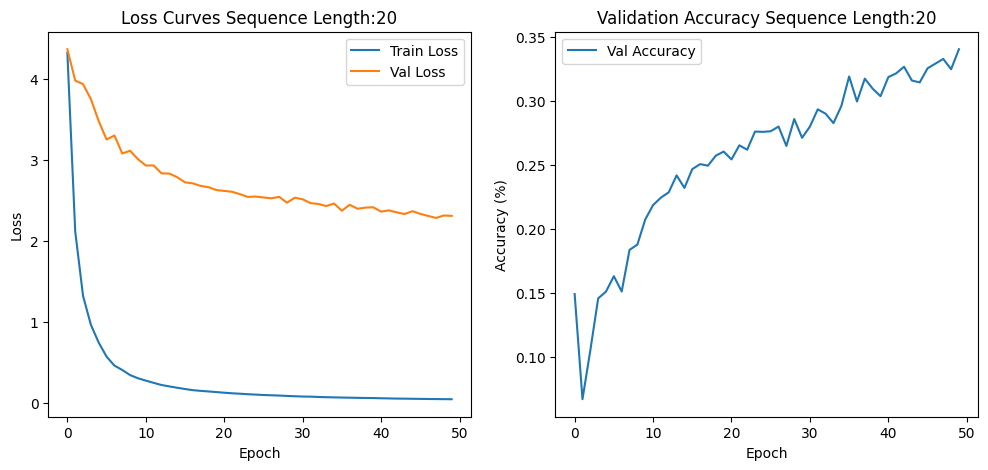

Layer (type:depth-idx)                        Output Shape              Param #
TransformerModel                              [1, 65]                   --
├─Embedding: 1-1                              [1, 65, 512]              33,280
├─PositionalEncoding: 1-2                     [1, 65, 512]              --
├─TransformerEncoder: 1-3                     [1, 65, 512]              --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 65, 512]              3,152,384
│    │    └─TransformerEncoderLayer: 3-2      [1, 65, 512]              3,152,384
├─Linear: 1-4                                 [1, 65]                   33,345
Total params: 6,371,393
Trainable params: 6,371,393
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.27
Input size (MB): 0.00
Forward/backward pass size (MB): 3.99
Params size (MB): 17.08
Estimated Total Size (MB): 21.08
Epoch 0, Loss: 2.7891, Val Accuracy: 0.2446, Val Loss: 2.7498
Tra

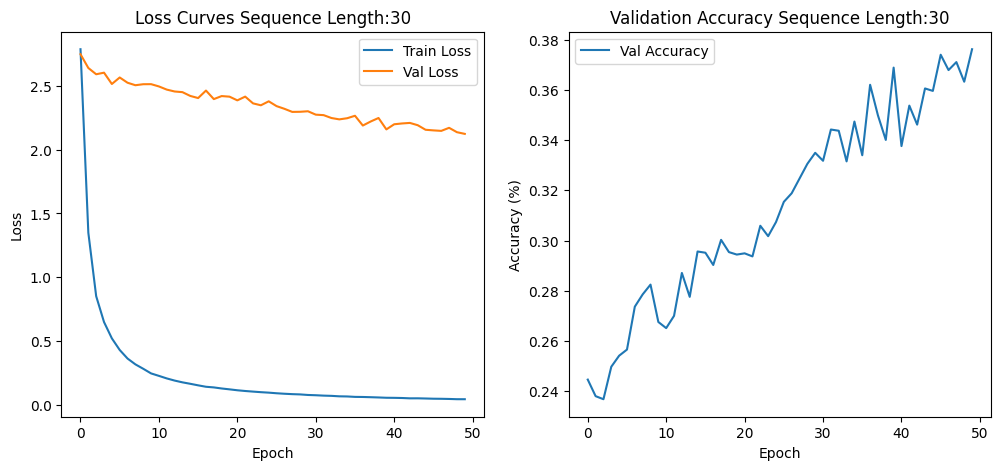

Layer (type:depth-idx)                        Output Shape              Param #
TransformerModel                              [1, 65]                   --
├─Embedding: 1-1                              [1, 65, 512]              33,280
├─PositionalEncoding: 1-2                     [1, 65, 512]              --
├─TransformerEncoder: 1-3                     [1, 65, 512]              --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 65, 512]              3,152,384
│    │    └─TransformerEncoderLayer: 3-2      [1, 65, 512]              3,152,384
├─Linear: 1-4                                 [1, 65]                   33,345
Total params: 6,371,393
Trainable params: 6,371,393
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.27
Input size (MB): 0.00
Forward/backward pass size (MB): 3.99
Params size (MB): 17.08
Estimated Total Size (MB): 21.08


In [ ]:
for seq_len in input_lengths:


# Training Loop
  #Lists for storing loss and validation values
  train_loss_list = []
  val_loss_list = []
  val_accuracy_list = []
  train_batches = 0

  #Create a new training loop for each input_length
  for epoch in range(epochs):
    X_train, y_train = get_batch('train', sequence_length=seq_len)

    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    start_event.record()
    model.train()

    epoch_train_loss = 0.0

    optimizer.zero_grad()
    y_pred = model(X_train)  # Forward pass
    loss = criterion(y_pred, y_train)  # Compute loss
    loss.backward()  # Backward pass
    optimizer.step()  # Update model parameters

    epoch_train_loss += loss.item()
    train_batches += 1

    end_event.record()
    torch.cuda.synchronize()
    # Calculate time in milliseconds
    elapsed_time_ms = start_event.elapsed_time(end_event)


# Validation Loop
    model.eval()

    total_val_loss = 0.0
    total_val_acc = 0.0
    val_batches = 0

    with torch.no_grad():
      X_val, y_val = get_batch('test', sequence_length=seq_len)

      val_output = model(X_val)
      val_loss = criterion(val_output, y_val) #Find the loss

      predicted = torch.argmax(val_output, 1) #Here we find what the output was (what letter)
      val_accuracy = (predicted == y_val).float().mean()

      total_val_loss += val_loss.item()
      total_val_acc += val_accuracy.item()
      val_batches += 1

    # Compute genuine averages across the whole dataset split
    avg_train_loss = epoch_train_loss / train_batches
    avg_val_loss = total_val_loss / val_batches
    avg_val_acc = total_val_acc / val_batches

    # Append true averages to history lists
    train_loss_list.append(avg_train_loss)
    val_loss_list.append(avg_val_loss)
    val_accuracy_list.append(avg_val_acc)

    if (epoch % 1 == 0):
      print(f'Epoch {epoch}, Loss: {avg_train_loss:.4f}, Val Accuracy: {avg_val_acc:.4f}, Val Loss: {avg_val_loss:.4f}')
      print(f"Training time for Epoch {epoch}: {elapsed_time_ms / 1000:.6f} seconds")
  createPlot(seq_len, train_loss_list, val_loss_list, val_accuracy_list)
  print(summary(model, input_size = (1,input_size), dtypes=[torch.long]))



In [ ]:
def predictNextChar(model, char_to_ix, ix_to_char, initial_str):
  model.eval()
  with torch.no_grad():
    initial_input = torch.tensor([char_to_ix[c] for c in initial_str], dtype=torch.long).unsqueeze(0).to(device)
    prediction = model(initial_input)
    predicted_index = torch.argmax(prediction, dim=1).item()
    return ix_to_char[predicted_index]

In [ ]:
test_str = " "
for _ in range(30):
  predicted_char = predictNextChar(model, char_to_ix, ix_to_char, test_str)
  test_str += predicted_char
  print(f"Predicted next character: '{test_str}'")

Predicted next character: ' f'
Predicted next character: ' fo'
Predicted next character: ' for'
Predicted next character: ' foro'
Predicted next character: ' forom'
Predicted next character: ' foroma'
Predicted next character: ' foroman'
Predicted next character: ' foromant'
Predicted next character: ' foromanth'
Predicted next character: ' foromantha'
Predicted next character: ' foromanthan'
Predicted next character: ' foromanthant'
Predicted next character: ' foromanthanth'
Predicted next character: ' foromanthantha'
Predicted next character: ' foromanthanthat'
Predicted next character: ' foromanthanthath'
Predicted next character: ' foromanthanthathe'
Predicted next character: ' foromanthanthathe '
Predicted next character: ' foromanthanthathe t'
Predicted next character: ' foromanthanthathe th'
Predicted next character: ' foromanthanthathe thi'
Predicted next character: ' foromanthanthathe this'
Predicted next character: ' foromanthanthathe this '
Predicted next character: ' foroma

# 4 transformer blocks, 2 heads

In [ ]:
#Hyperparameters
num_layers = 4
nhead = 2


model = TransformerModel(len(sorted_text), len(sorted_text), hidden_size, nhead, num_layers).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = lr)

Epoch 0, Loss: 4.4025, Val Accuracy: 0.1531, Val Loss: 5.0132
Training time for Epoch 0: 0.432276 seconds
Epoch 1, Loss: 2.4479, Val Accuracy: 0.0901, Val Loss: 4.1339
Training time for Epoch 1: 0.432235 seconds
Epoch 2, Loss: 1.3919, Val Accuracy: 0.0427, Val Loss: 4.0365
Training time for Epoch 2: 0.432100 seconds
Epoch 3, Loss: 1.0051, Val Accuracy: 0.0415, Val Loss: 3.7250
Training time for Epoch 3: 0.432373 seconds
Epoch 4, Loss: 0.7401, Val Accuracy: 0.1611, Val Loss: 3.4346
Training time for Epoch 4: 0.432080 seconds
Epoch 5, Loss: 0.5687, Val Accuracy: 0.1589, Val Loss: 3.4479
Training time for Epoch 5: 0.432769 seconds
Epoch 6, Loss: 0.4905, Val Accuracy: 0.1460, Val Loss: 3.4386
Training time for Epoch 6: 0.432140 seconds
Epoch 7, Loss: 0.4216, Val Accuracy: 0.0793, Val Loss: 3.4163
Training time for Epoch 7: 0.432180 seconds
Epoch 8, Loss: 0.3736, Val Accuracy: 0.0864, Val Loss: 3.3686
Training time for Epoch 8: 0.432230 seconds
Epoch 9, Loss: 0.3340, Val Accuracy: 0.0598, V

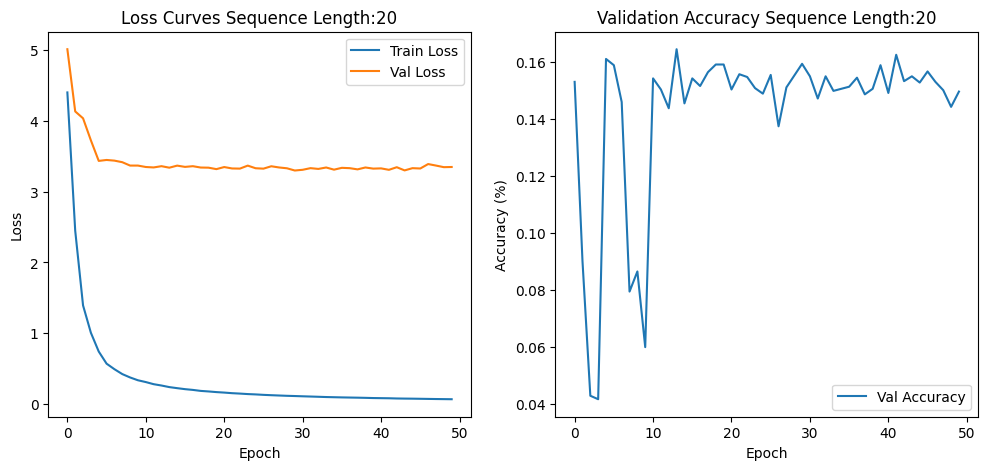

Layer (type:depth-idx)                        Output Shape              Param #
TransformerModel                              [1, 65]                   --
├─Embedding: 1-1                              [1, 65, 512]              33,280
├─PositionalEncoding: 1-2                     [1, 65, 512]              --
├─TransformerEncoder: 1-3                     [1, 65, 512]              --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 65, 512]              3,152,384
│    │    └─TransformerEncoderLayer: 3-2      [1, 65, 512]              3,152,384
│    │    └─TransformerEncoderLayer: 3-3      [1, 65, 512]              3,152,384
│    │    └─TransformerEncoderLayer: 3-4      [1, 65, 512]              3,152,384
├─Linear: 1-4                                 [1, 65]                   33,345
Total params: 12,676,161
Trainable params: 12,676,161
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 8.47
Input size (MB):

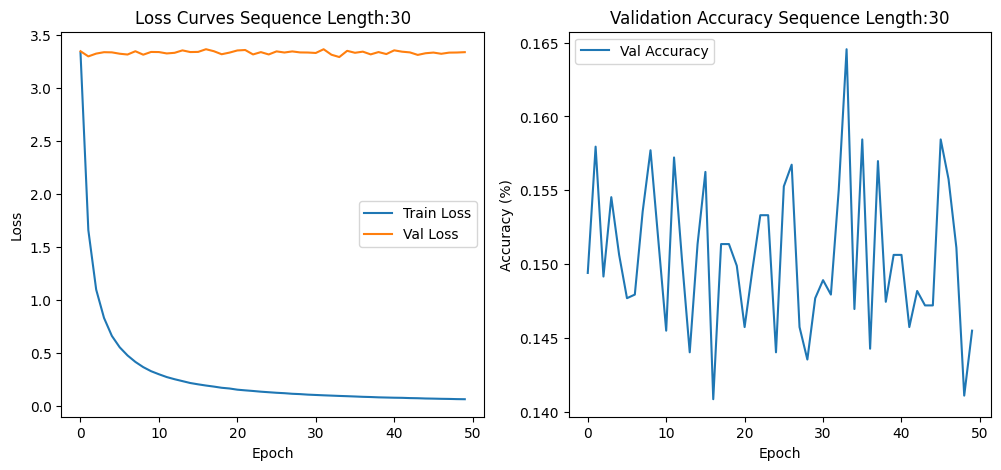

Layer (type:depth-idx)                        Output Shape              Param #
TransformerModel                              [1, 65]                   --
├─Embedding: 1-1                              [1, 65, 512]              33,280
├─PositionalEncoding: 1-2                     [1, 65, 512]              --
├─TransformerEncoder: 1-3                     [1, 65, 512]              --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 65, 512]              3,152,384
│    │    └─TransformerEncoderLayer: 3-2      [1, 65, 512]              3,152,384
│    │    └─TransformerEncoderLayer: 3-3      [1, 65, 512]              3,152,384
│    │    └─TransformerEncoderLayer: 3-4      [1, 65, 512]              3,152,384
├─Linear: 1-4                                 [1, 65]                   33,345
Total params: 12,676,161
Trainable params: 12,676,161
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 8.47
Input size (MB):

In [ ]:
for seq_len in input_lengths:


# Training Loop
  #Lists for storing loss and validation values
  train_loss_list = []
  val_loss_list = []
  val_accuracy_list = []
  train_batches = 0

  #Create a new training loop for each input_length
  for epoch in range(epochs):
    X_train, y_train = get_batch('train', sequence_length=seq_len)

    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    start_event.record()
    model.train()

    epoch_train_loss = 0.0

    optimizer.zero_grad()
    y_pred = model(X_train)  # Forward pass
    loss = criterion(y_pred, y_train)  # Compute loss
    loss.backward()  # Backward pass
    optimizer.step()  # Update model parameters

    epoch_train_loss += loss.item()
    train_batches += 1

    end_event.record()
    torch.cuda.synchronize()
    # Calculate time in milliseconds
    elapsed_time_ms = start_event.elapsed_time(end_event)


# Validation Loop
    model.eval()

    total_val_loss = 0.0
    total_val_acc = 0.0
    val_batches = 0

    with torch.no_grad():
      X_val, y_val = get_batch('test', sequence_length=seq_len)

      val_output = model(X_val)
      val_loss = criterion(val_output, y_val) #Find the loss

      predicted = torch.argmax(val_output, 1) #Here we find what the output was (what letter)
      val_accuracy = (predicted == y_val).float().mean()

      total_val_loss += val_loss.item()
      total_val_acc += val_accuracy.item()
      val_batches += 1

    # Compute genuine averages across the whole dataset split
    avg_train_loss = epoch_train_loss / train_batches
    avg_val_loss = total_val_loss / val_batches
    avg_val_acc = total_val_acc / val_batches

    # Append true averages to history lists
    train_loss_list.append(avg_train_loss)
    val_loss_list.append(avg_val_loss)
    val_accuracy_list.append(avg_val_acc)

    if (epoch % 1 == 0):
      print(f'Epoch {epoch}, Loss: {avg_train_loss:.4f}, Val Accuracy: {avg_val_acc:.4f}, Val Loss: {avg_val_loss:.4f}')
      print(f"Training time for Epoch {epoch}: {elapsed_time_ms / 1000:.6f} seconds")
  createPlot(seq_len, train_loss_list, val_loss_list, val_accuracy_list)
  print(summary(model, input_size = (1,input_size), dtypes=[torch.long]))



In [ ]:
def predictNextChar(model, char_to_ix, ix_to_char, initial_str):
  model.eval()
  with torch.no_grad():
    initial_input = torch.tensor([char_to_ix[c] for c in initial_str], dtype=torch.long).unsqueeze(0).to(device)
    prediction = model(initial_input)
    predicted_index = torch.argmax(prediction, dim=1).item()
    return ix_to_char[predicted_index]

In [ ]:
test_str = " "
for _ in range(30):
  predicted_char = predictNextChar(model, char_to_ix, ix_to_char, test_str)
  test_str += predicted_char
  print(f"Predicted next character: '{test_str}'")

Predicted next character: '  '
Predicted next character: '   '
Predicted next character: '    '
Predicted next character: '     '
Predicted next character: '      '
Predicted next character: '       '
Predicted next character: '        '
Predicted next character: '         '
Predicted next character: '          '
Predicted next character: '           '
Predicted next character: '            '
Predicted next character: '             '
Predicted next character: '              '
Predicted next character: '               '
Predicted next character: '                '
Predicted next character: '                 '
Predicted next character: '                  '
Predicted next character: '                   '
Predicted next character: '                    '
Predicted next character: '                     '
Predicted next character: '                      '
Predicted next character: '                       '
Predicted next character: '                        '
Predicted next character: '       

# 4 transformer blocks, 4 heads

In [ ]:
#Hyperparameters
num_layers = 4
nhead = 4


model = TransformerModel(len(sorted_text), len(sorted_text), hidden_size, nhead, num_layers).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = lr)

Epoch 0, Loss: 4.1795, Val Accuracy: 0.1489, Val Loss: 4.8323
Training time for Epoch 0: 0.439841 seconds
Epoch 1, Loss: 2.3757, Val Accuracy: 0.0742, Val Loss: 4.6825
Training time for Epoch 1: 0.440473 seconds
Epoch 2, Loss: 1.5359, Val Accuracy: 0.0427, Val Loss: 4.3505
Training time for Epoch 2: 0.439738 seconds
Epoch 3, Loss: 1.0783, Val Accuracy: 0.0642, Val Loss: 4.1190
Training time for Epoch 3: 0.440196 seconds
Epoch 4, Loss: 0.8159, Val Accuracy: 0.0605, Val Loss: 3.7547
Training time for Epoch 4: 0.439734 seconds
Epoch 5, Loss: 0.6231, Val Accuracy: 0.1443, Val Loss: 3.5526
Training time for Epoch 5: 0.439699 seconds
Epoch 6, Loss: 0.5055, Val Accuracy: 0.1387, Val Loss: 3.5886
Training time for Epoch 6: 0.439679 seconds
Epoch 7, Loss: 0.4416, Val Accuracy: 0.1582, Val Loss: 3.3833
Training time for Epoch 7: 0.439810 seconds
Epoch 8, Loss: 0.3716, Val Accuracy: 0.1462, Val Loss: 3.3672
Training time for Epoch 8: 0.439649 seconds
Epoch 9, Loss: 0.3359, Val Accuracy: 0.0884, V

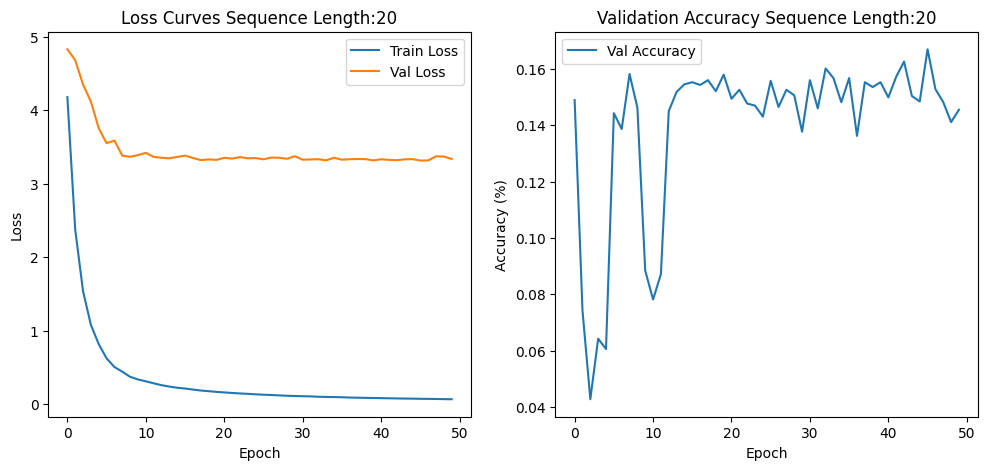

Layer (type:depth-idx)                        Output Shape              Param #
TransformerModel                              [1, 65]                   --
├─Embedding: 1-1                              [1, 65, 512]              33,280
├─PositionalEncoding: 1-2                     [1, 65, 512]              --
├─TransformerEncoder: 1-3                     [1, 65, 512]              --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 65, 512]              3,152,384
│    │    └─TransformerEncoderLayer: 3-2      [1, 65, 512]              3,152,384
│    │    └─TransformerEncoderLayer: 3-3      [1, 65, 512]              3,152,384
│    │    └─TransformerEncoderLayer: 3-4      [1, 65, 512]              3,152,384
├─Linear: 1-4                                 [1, 65]                   33,345
Total params: 12,676,161
Trainable params: 12,676,161
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 8.47
Input size (MB):

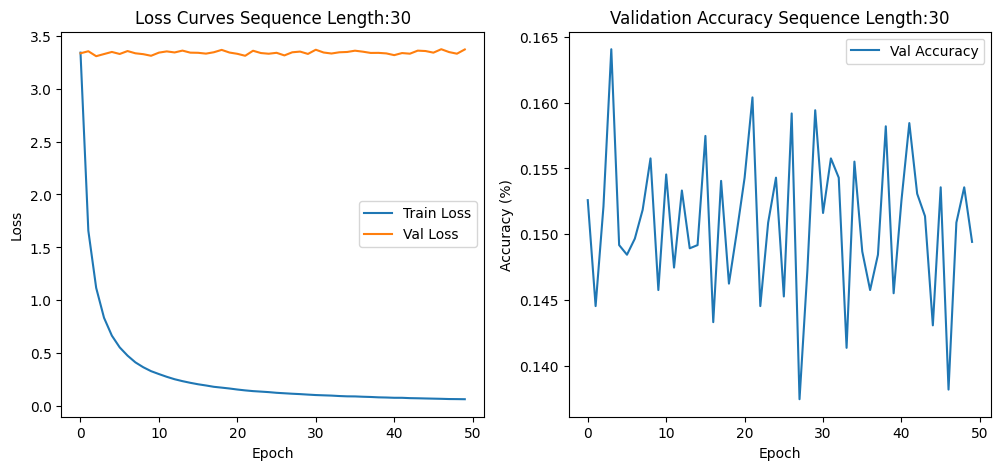

Layer (type:depth-idx)                        Output Shape              Param #
TransformerModel                              [1, 65]                   --
├─Embedding: 1-1                              [1, 65, 512]              33,280
├─PositionalEncoding: 1-2                     [1, 65, 512]              --
├─TransformerEncoder: 1-3                     [1, 65, 512]              --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 65, 512]              3,152,384
│    │    └─TransformerEncoderLayer: 3-2      [1, 65, 512]              3,152,384
│    │    └─TransformerEncoderLayer: 3-3      [1, 65, 512]              3,152,384
│    │    └─TransformerEncoderLayer: 3-4      [1, 65, 512]              3,152,384
├─Linear: 1-4                                 [1, 65]                   33,345
Total params: 12,676,161
Trainable params: 12,676,161
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 8.47
Input size (MB):

In [ ]:
for seq_len in input_lengths:
# Training Loop
  #Lists for storing loss and validation values
  train_loss_list = []
  val_loss_list = []
  val_accuracy_list = []
  train_batches = 0

  #Create a new training loop for each input_length
  for epoch in range(epochs):
    X_train, y_train = get_batch('train', sequence_length=seq_len)

    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    start_event.record()
    model.train()

    epoch_train_loss = 0.0

    optimizer.zero_grad()
    y_pred = model(X_train)  # Forward pass
    loss = criterion(y_pred, y_train)  # Compute loss
    loss.backward()  # Backward pass
    optimizer.step()  # Update model parameters

    epoch_train_loss += loss.item()
    train_batches += 1

    end_event.record()
    torch.cuda.synchronize()
    # Calculate time in milliseconds
    elapsed_time_ms = start_event.elapsed_time(end_event)


# Validation Loop
    model.eval()

    total_val_loss = 0.0
    total_val_acc = 0.0
    val_batches = 0

    with torch.no_grad():
      X_val, y_val = get_batch('test', sequence_length=seq_len)

      val_output = model(X_val)
      val_loss = criterion(val_output, y_val) #Find the loss

      predicted = torch.argmax(val_output, 1) #Here we find what the output was (what letter)
      val_accuracy = (predicted == y_val).float().mean()

      total_val_loss += val_loss.item()
      total_val_acc += val_accuracy.item()
      val_batches += 1

    # Compute genuine averages across the whole dataset split
    avg_train_loss = epoch_train_loss / train_batches
    avg_val_loss = total_val_loss / val_batches
    avg_val_acc = total_val_acc / val_batches

    # Append true averages to history lists
    train_loss_list.append(avg_train_loss)
    val_loss_list.append(avg_val_loss)
    val_accuracy_list.append(avg_val_acc)

    if (epoch % 1 == 0):
      print(f'Epoch {epoch}, Loss: {avg_train_loss:.4f}, Val Accuracy: {avg_val_acc:.4f}, Val Loss: {avg_val_loss:.4f}')
      print(f"Training time for Epoch {epoch}: {elapsed_time_ms / 1000:.6f} seconds")
  createPlot(seq_len, train_loss_list, val_loss_list, val_accuracy_list)
  print(summary(model, input_size = (1,input_size), dtypes=[torch.long]))



In [ ]:
def predictNextChar(model, char_to_ix, ix_to_char, initial_str):
  model.eval()
  with torch.no_grad():
    initial_input = torch.tensor([char_to_ix[c] for c in initial_str], dtype=torch.long).unsqueeze(0).to(device)
    prediction = model(initial_input)
    predicted_index = torch.argmax(prediction, dim=1).item()
    return ix_to_char[predicted_index]

In [ ]:
test_str = " "
for _ in range(30):
  predicted_char = predictNextChar(model, char_to_ix, ix_to_char, test_str)
  test_str += predicted_char
  print(f"Predicted next character: '{test_str}'")

Predicted next character: '  '
Predicted next character: '   '
Predicted next character: '    '
Predicted next character: '     '
Predicted next character: '      '
Predicted next character: '       '
Predicted next character: '        '
Predicted next character: '         '
Predicted next character: '          '
Predicted next character: '           '
Predicted next character: '            '
Predicted next character: '             '
Predicted next character: '              '
Predicted next character: '               '
Predicted next character: '                '
Predicted next character: '                 '
Predicted next character: '                  '
Predicted next character: '                   '
Predicted next character: '                    '
Predicted next character: '                     '
Predicted next character: '                      '
Predicted next character: '                       '
Predicted next character: '                        '
Predicted next character: '       

# 4 transformer blocks, 4 heads, sequence length 50

In [ ]:
#Hyperparameters
input_lengths = [50]
num_layers = 2
nhead = 4


model = TransformerModel(len(sorted_text), len(sorted_text), hidden_size, nhead, num_layers).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = lr)

Epoch 0, Loss: 4.4077, Val Accuracy: 0.1648, Val Loss: 4.8331
Training time for Epoch 0: 1.079933 seconds
Epoch 1, Loss: 2.4473, Val Accuracy: 0.0847, Val Loss: 4.4491
Training time for Epoch 1: 1.042628 seconds
Epoch 2, Loss: 1.4545, Val Accuracy: 0.0542, Val Loss: 4.2465
Training time for Epoch 2: 1.042336 seconds
Epoch 3, Loss: 1.0607, Val Accuracy: 0.0452, Val Loss: 4.0026
Training time for Epoch 3: 1.041349 seconds
Epoch 4, Loss: 0.8006, Val Accuracy: 0.0454, Val Loss: 3.6852
Training time for Epoch 4: 1.042167 seconds
Epoch 5, Loss: 0.6138, Val Accuracy: 0.1511, Val Loss: 3.4490
Training time for Epoch 5: 1.041757 seconds
Epoch 6, Loss: 0.4929, Val Accuracy: 0.1431, Val Loss: 3.5467
Training time for Epoch 6: 1.041197 seconds
Epoch 7, Loss: 0.4328, Val Accuracy: 0.1553, Val Loss: 3.3843
Training time for Epoch 7: 1.041810 seconds
Epoch 8, Loss: 0.3732, Val Accuracy: 0.0813, Val Loss: 3.4193
Training time for Epoch 8: 1.041345 seconds
Epoch 9, Loss: 0.3348, Val Accuracy: 0.0774, V

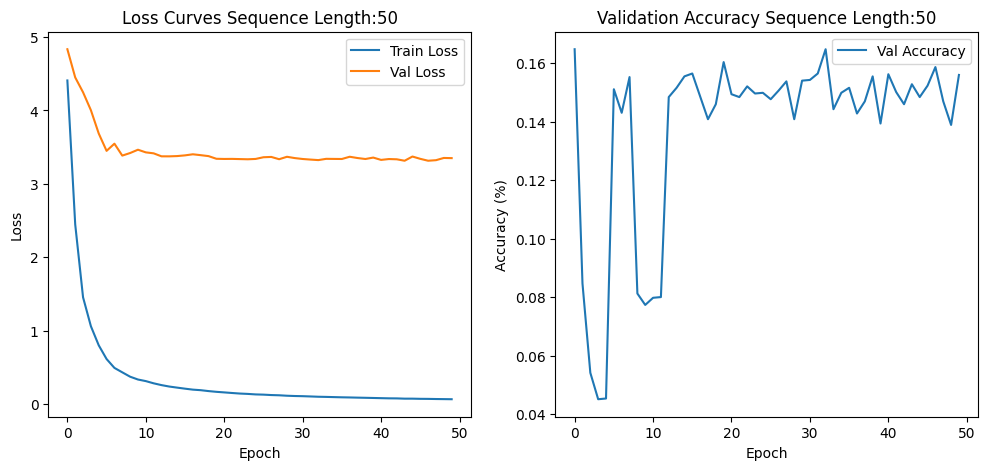

Layer (type:depth-idx)                        Output Shape              Param #
TransformerModel                              [1, 65]                   --
├─Embedding: 1-1                              [1, 65, 512]              33,280
├─PositionalEncoding: 1-2                     [1, 65, 512]              --
├─TransformerEncoder: 1-3                     [1, 65, 512]              --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 65, 512]              3,152,384
│    │    └─TransformerEncoderLayer: 3-2      [1, 65, 512]              3,152,384
│    │    └─TransformerEncoderLayer: 3-3      [1, 65, 512]              3,152,384
│    │    └─TransformerEncoderLayer: 3-4      [1, 65, 512]              3,152,384
├─Linear: 1-4                                 [1, 65]                   33,345
Total params: 12,676,161
Trainable params: 12,676,161
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 8.47
Input size (MB):

In [ ]:
for seq_len in input_lengths:
# Training Loop
  #Lists for storing loss and validation values
  train_loss_list = []
  val_loss_list = []
  val_accuracy_list = []
  train_batches = 0

  #Create a new training loop for each input_length
  for epoch in range(epochs):
    X_train, y_train = get_batch('train', sequence_length=seq_len)

    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    start_event.record()
    model.train()

    epoch_train_loss = 0.0

    optimizer.zero_grad()
    y_pred = model(X_train)  # Forward pass
    loss = criterion(y_pred, y_train)  # Compute loss
    loss.backward()  # Backward pass
    optimizer.step()  # Update model parameters

    epoch_train_loss += loss.item()
    train_batches += 1

    end_event.record()
    torch.cuda.synchronize()
    # Calculate time in milliseconds
    elapsed_time_ms = start_event.elapsed_time(end_event)


# Validation Loop
    model.eval()

    total_val_loss = 0.0
    total_val_acc = 0.0
    val_batches = 0

    with torch.no_grad():
      X_val, y_val = get_batch('test', sequence_length=seq_len)

      val_output = model(X_val)
      val_loss = criterion(val_output, y_val) #Find the loss

      predicted = torch.argmax(val_output, 1) #Here we find what the output was (what letter)
      val_accuracy = (predicted == y_val).float().mean()

      total_val_loss += val_loss.item()
      total_val_acc += val_accuracy.item()
      val_batches += 1

    # Compute genuine averages across the whole dataset split
    avg_train_loss = epoch_train_loss / train_batches
    avg_val_loss = total_val_loss / val_batches
    avg_val_acc = total_val_acc / val_batches

    # Append true averages to history lists
    train_loss_list.append(avg_train_loss)
    val_loss_list.append(avg_val_loss)
    val_accuracy_list.append(avg_val_acc)

    if (epoch % 1 == 0):
      print(f'Epoch {epoch}, Loss: {avg_train_loss:.4f}, Val Accuracy: {avg_val_acc:.4f}, Val Loss: {avg_val_loss:.4f}')
      print(f"Training time for Epoch {epoch}: {elapsed_time_ms / 1000:.6f} seconds")
  createPlot(seq_len, train_loss_list, val_loss_list, val_accuracy_list)
  print(summary(model, input_size = (1,input_size), dtypes=[torch.long]))



In [ ]:
def predictNextChar(model, char_to_ix, ix_to_char, initial_str):
  model.eval()
  with torch.no_grad():
    initial_input = torch.tensor([char_to_ix[c] for c in initial_str], dtype=torch.long).unsqueeze(0).to(device)
    prediction = model(initial_input)
    predicted_index = torch.argmax(prediction, dim=1).item()
    return ix_to_char[predicted_index]

In [ ]:
test_str = " "
for _ in range(30):
  predicted_char = predictNextChar(model, char_to_ix, ix_to_char, test_str)
  test_str += predicted_char
  print(f"Predicted next character: '{test_str}'")

Predicted next character: '  '
Predicted next character: '   '
Predicted next character: '    '
Predicted next character: '     '
Predicted next character: '      '
Predicted next character: '       '
Predicted next character: '        '
Predicted next character: '         '
Predicted next character: '          '
Predicted next character: '           '
Predicted next character: '            '
Predicted next character: '             '
Predicted next character: '              '
Predicted next character: '               '
Predicted next character: '                '
Predicted next character: '                 '
Predicted next character: '                  '
Predicted next character: '                   '
Predicted next character: '                    '
Predicted next character: '                     '
Predicted next character: '                      '
Predicted next character: '                       '
Predicted next character: '                        '
Predicted next character: '       